# 🩸 Practice Using Diabetes Patient Data

The Diabetes dataset contains data from a total of 442 diabetes patients.
It includes age, sex, body mass index, average blood pressure, and six serum measurements.
This dataset represents examination results from 442 diabetes patients.

Target data: The disease progression measured one year after baseline

Feature data: (All feature data in this dataset are normalized values)

  - Age
  - Sex
  - Body mass index
  - Average blood pressure
  - S1
  - S2
  - S3
  - S4
  - S5
  - S6


In [123]:
import matplotlib.pylab as plt

%matplotlib inline
import pandas as pd
import numpy as np

---
load `diabetes` data

In [124]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

---
print size of your data and target

In [125]:
print(diabetes.data.shape)  # feature matrix shape
print(diabetes.target.shape)  # target vector shape

(442, 10)
(442,)


---
print feature names

In [126]:
diabetes.feature_names  # column names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

---
What do s1, s2 and s6 represent?

In [127]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

## Single Linear Regression Model

---
- pick one of the features.
- define X and y
- print shape of X and y

In [128]:
print("selected feature:", diabetes.feature_names[2])
X = diabetes.data[:, 2]  # bmi
y = diabetes.target

selected feature: bmi


---
Split train and test data

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), y)

---
- print shape of X and y
- print shape of X_train and y_train

In [130]:
X.shape, y.shape, X_train.shape, y_train.shape

((442,), (442,), (331, 1), (331,))

---
- Create a regression model
- Check the R² value of the created regression model.

In [131]:
from sklearn.linear_model import LinearRegression

In [132]:
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.369840143977231

---
What is the coefficient and intercept?

In [133]:
print(model.coef_)  # Get the coefficients
print("")
print(model.intercept_)  # Get the intercept

[917.25040168]

153.31761906994285


---
What is R^2?

In [134]:
r2 = model.score(X_train, y_train)
r2

0.3335112056955446

---
What is RMSE?

In [135]:
from sklearn.metrics import root_mean_squared_error

y_pred = model.predict(X_test)


print("MSE = ", root_mean_squared_error(y_test, y_pred))

MSE =  62.717097306140076


## Multi Linear Regression Model

---
- Define X and y
- Split train and test data using 80:20 ratio


In [136]:
X = diabetes.data
y = diabetes.target

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

---

- Create a regression model
- Check the R² value of the created regression model.

In [138]:
# 1. Set up the model
model = LinearRegression()
# 2. Use fit
model.fit(X_train, y_train)
# 3. Check the score
model.score(X_test, y_test)

0.33223321731061817

---
What is the coefficient and intercept?

In [139]:
print(model.coef_)  # Get the coefficients
print("")
print(model.intercept_)  # Get the intercept

[ -35.55025079 -243.16508959  562.76234744  305.46348218 -662.70290089
  324.20738537   24.74879489  170.3249615   731.63743545   43.0309307 ]

152.5380470138517


---
What is root mean squared error?

In [140]:
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(
    y_test,
    y_pred,
)

print(f"RMSE = {rmse}")

RMSE = 58.517171277315626


---

Visualize the test data and the model's predictions using a graph.

If the model performs well, the predicted values will align closely with the 45-degree diagonal line.

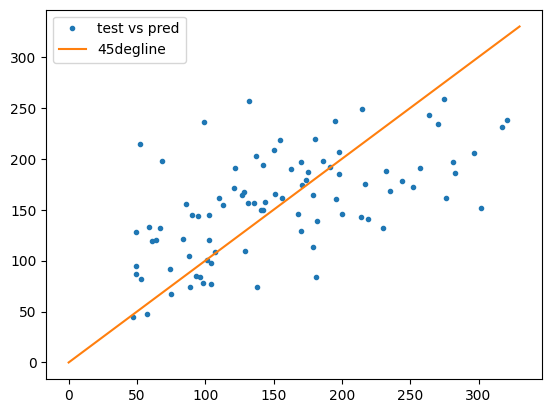

In [141]:
# plot prediction and actual data
plt.plot(y_test, y_pred, ".")

# plot a line, a perfit predict would all fall on this line
x = np.linspace(0, 330, 50)
y = np.linspace(0, 330, 50)
plt.plot(x, y, "-")  # draw y=1*x graph

plt.legend(["test vs pred", "45degline"])
plt.show()

---
Make summary table of coefficient and sort by its absolute value

In [142]:
coefdf = pd.DataFrame({"feat": diabetes.feature_names, "coef": model.coef_})
coefdf["abs_coef"] = coefdf["coef"].map(abs)
coefdf.sort_values("abs_coef")

,feat,coef,abs_coef
6,s3,24.748795,24.748795
0,age,-35.550251,35.550251
9,s6,43.030931,43.030931
7,s4,170.324962,170.324962
1,sex,-243.165090,243.165090
3,bp,305.463482,305.463482
5,s2,324.207385,324.207385
2,bmi,562.762347,562.762347
4,s1,-662.702901,662.702901
8,s5,731.637435,731.637435


---
In the standardized regression model, some regression coefficients are very small. This means that the corresponding variables have very little influence in the model. What would happen if we removed those?

In [143]:
X_train_simple = X_train[:, [7, 1, 3, 5, 2, 4, 8]]
X_test_simple = X_test[:, [7, 1, 3, 5, 2, 4, 8]]

In [144]:
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [153]:
# recall

print(model.score(X_test, y_test))
rmse = root_mean_squared_error(
    y_test,
    model.predict(X_test),
)
print(f"RMSE = {rmse}")

0.33223321731061817
RMSE = 58.517171277315626


In [156]:
# Check our new model result

print(model_simple.score(X_test_simple, y_test))
rmse = root_mean_squared_error(
    y_test,
    model_simple.predict(X_test_simple),
)
print(f"RMSE = {rmse}")

0.3306896427877103
RMSE = 58.58476484391338


Removing those unimportant variables, which have very little influence on the model, does not significantly affect the prediction results of the regression equation.

> Occam's Razor
> 
> Also known as the Principle of Economy, the Law of Parsimony (lex parsimoniae), or the Principle of Simplicity. In regression modeling, this means that removing unnecessary variables and building a simpler model often leads to a better model.:

# 🏘️ Practice: Housing Dataset


## **Problem Description**
In this exercise, we will use the **California Housing Dataset** to perform **Single Linear Regression**. We will predict the **median house value** (in $1000s) based on a single feature. This example uses **'RM'** (average number of rooms per dwelling) as the independent variable, and the goal is to predict the target variable, which is the median house value, **'MEDV'**.

### **Exercise Steps**
1. **Load the Data**: Load the california housing dataset and understand the features.
2. **Data Exploration**: Explore the relationship between the selected feature ('RM') and the target ('MEDV').
3. **Train a Linear Regression Model**: 
   - Use the 'RM' feature to train a linear regression model.
   - Visualize the regression line and make predictions.
4. **Evaluate the Model**: Calculate the Mean Squared Error (MSE) or R-squared to evaluate the model's performance.

### **Questions**
1. **How well does the number of rooms explain the variation in house prices?**
   - Look at the R-squared value and interpret its significance.
2. **How well does the linear regression line fit the data?**
   - Visualize the scatter plot of the data points along with the fitted line.
3. **What are the key insights you can draw from this model?**
   - Discuss the relationship between the number of rooms and house prices based on the regression line.

### **Expected Results**
- **Scatter Plot and Line**: You should see a clear upward trend on the scatter plot, as more rooms generally correlate with a higher house price.
- **R-squared Value**: The R-squared value should indicate how well the 'RM' feature explains the variation in house prices. A higher value (closer to 1) indicates a better fit.
- **Model Interpretation**: The regression model should provide a coefficient for 'RM', showing how much the price changes for each additional room.

### **Learning Points**
- **Single Linear Regression** is useful for understanding the relationship between one independent variable and one dependent variable.
- The **R-squared value** helps assess the model's explanatory power. It shows the proportion of variance in the target variable that is predictable from the independent variable.
- **Data visualization** (scatter plot and regression line) is essential to better understand the relationship between the variables.


In [73]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)
df["MedHouseVal"] = california.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [74]:
X = df["AveRooms"].values.reshape(-1, 1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
reg.score(X_test, y_test)

0.026842525984574483

In [76]:
from sklearn.metrics import root_mean_squared_error

result = reg.predict(X_test)
mse = root_mean_squared_error(y_test, result)
mse

1.146865666430222

In [77]:
reg.predict([[10], [5.3], [4.8], [3.5]])

array([2.36247514, 2.05486381, 2.0221392 , 1.93705521])